# Regressao Harmonica Sazonal para Previsao de Saude Financeira Familiar

## 1. Contextualizacao e Motivacao

Em problemas de financas pessoais com **baixa volumetria** -- tipicamente 6 a 24 registros mensais de saldo --, os metodos classicos de series temporais como **ARIMA** (Box-Jenkins) e **Prophet** (Meta) apresentam limitacoes fundamentais. Ambos exigem um numero minimo de observacoes para estimar parametros de autocorrelacao e componentes sazonais de forma confiavel, e frequentemente divergem no cenario de *cold-start*.

O **Principio da Parcimonia** (Navalha de Occam) orienta que, entre dois modelos com desempenho preditivo semelhante, deve-se preferir o de **menor complexidade**. A Regressao Harmonica Sazonal resolve esse trade-off ao impor uma estrutura parametrica explicita -- com apenas **4 parametros** -- que captura simultaneamente a tendencia linear de longo prazo e o padrao sazonal anual.

**Janela de Analise:** Jul/2025 a Jun/2026 (12 meses)

## 2. Formulação Matematica

$$\hat{y}_t = \beta_0 + \beta_1 \cdot t + \beta_2 \cdot \sin\!\left(\frac{2\pi \, t}{12}\right) + \beta_3 \cdot \cos\!\left(\frac{2\pi \, t}{12}\right)$$

Onde:
- **$\beta_0$** (intercepto): saldo medio de referencia no tempo zero.
- **$\beta_1$** (coeficiente de tendencia): taxa de variacao linear mensal do saldo.
- **$\beta_2$** e **$\beta_3$** (coeficientes harmonicos): amplitudes das componentes senoidal e cosenoidal, modelando o ciclo sazonal anual com periodo fixo de 12 meses.

A solucao dos coeficientes e obtida por **Minimos Quadrados Ordinarios (OLS)**, resolvendo o sistema de equacoes normais:

$$\mathbf{A}^T \mathbf{A} \, \boldsymbol{\beta} = \mathbf{A}^T \mathbf{y}$$

O sistema linear e resolvido pelo metodo de **Gauss-Jordan com pivoteamento parcial**, implementado em Python puro (sem dependencias externas).

## 3. Intervalos de Confianca

$$IC_{95\%} = \hat{y}_t \;\pm\; 1.96 \cdot SE \cdot \sqrt{k}$$

onde $SE$ e o erro padrao dos residuos e $k$ e o numero de passos a frente.


In [1]:
# --- Imports ---
import math
import sqlite3
import warnings
from datetime import datetime, date
from typing import List, Dict, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

# --- Visual style ---
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 150,
    "figure.figsize": (12, 5), "axes.titlesize": 14, "axes.labelsize": 12,
    "lines.linewidth": 2, "lines.markersize": 6, "legend.fontsize": 11,
    "figure.facecolor": "white",
})
PALETTE = sns.color_palette("viridis", 6)
print("OK: Bibliotecas importadas e estilo visual configurado.")


OK: Bibliotecas importadas e estilo visual configurado.


In [2]:
# --- Carregamento de dados reais do banco ---
# Constroi a serie temporal de fluxo de caixa mensal a partir de transacoes CONFIRMED.
# Janela de analise: Jul/2025 a Jun/2026 (12 meses)

import os
DB_PATH = os.path.join(os.path.dirname(os.getcwd()), "moneyin.db")
if not os.path.exists(DB_PATH):
    DB_PATH = "moneyin.db"

conn = sqlite3.connect(DB_PATH)
query = '''
    SELECT
        strftime('%Y-%m', "date") AS month,
        SUM(CASE WHEN amount > 0 THEN amount ELSE 0 END) AS income,
        SUM(CASE WHEN amount < 0 THEN ABS(amount) ELSE 0 END) AS expenses,
        SUM(amount) AS net_flow,
        COUNT(*) AS n_tx
    FROM "transaction"
    WHERE status = 'CONFIRMED' AND is_transfer = 0
    GROUP BY month
    ORDER BY month
'''
df_monthly = pd.read_sql_query(query, conn)
conn.close()

# Build the time series
df_monthly["date"] = pd.to_datetime(df_monthly["month"] + "-01")
df_monthly.set_index("date", inplace=True)
df = df_monthly[["net_flow"]].rename(columns={"net_flow": "balance"})

# Filtro: janela de 12 meses (Jul/2025 a Jun/2026)
df = df.loc['2025-07-01':'2026-06-30']

print(f'OK: Dados reais carregados de {DB_PATH}')
print(f'  Periodo: {df.index[0]:%b/%Y} a {df.index[-1]:%b/%Y} ({len(df)} meses)')
print(f'  Fluxo de caixa total: R$ {df["balance"].sum():,.2f}')
print(f'  Media mensal: R$ {df["balance"].mean():,.2f}')
display(df)


OK: Dados reais carregados de E:\02 - repos\moneyin\moneyin.db
  Periodo: Jul/2025 a Jun/2026 (12 meses)
  Fluxo de caixa total: R$ 37,088.92
  Media mensal: R$ 3,090.74


,balance
date,
2025-07-01,-1277.68
2025-08-01,8872.09
2025-09-01,3191.64
2025-10-01,-1717.40
2025-11-01,1569.90
2025-12-01,12510.80
2026-01-01,2250.22
2026-02-01,3348.98
2026-03-01,3196.88


Decomp: Periodo = 6 meses (maximo para 12 observacoes)


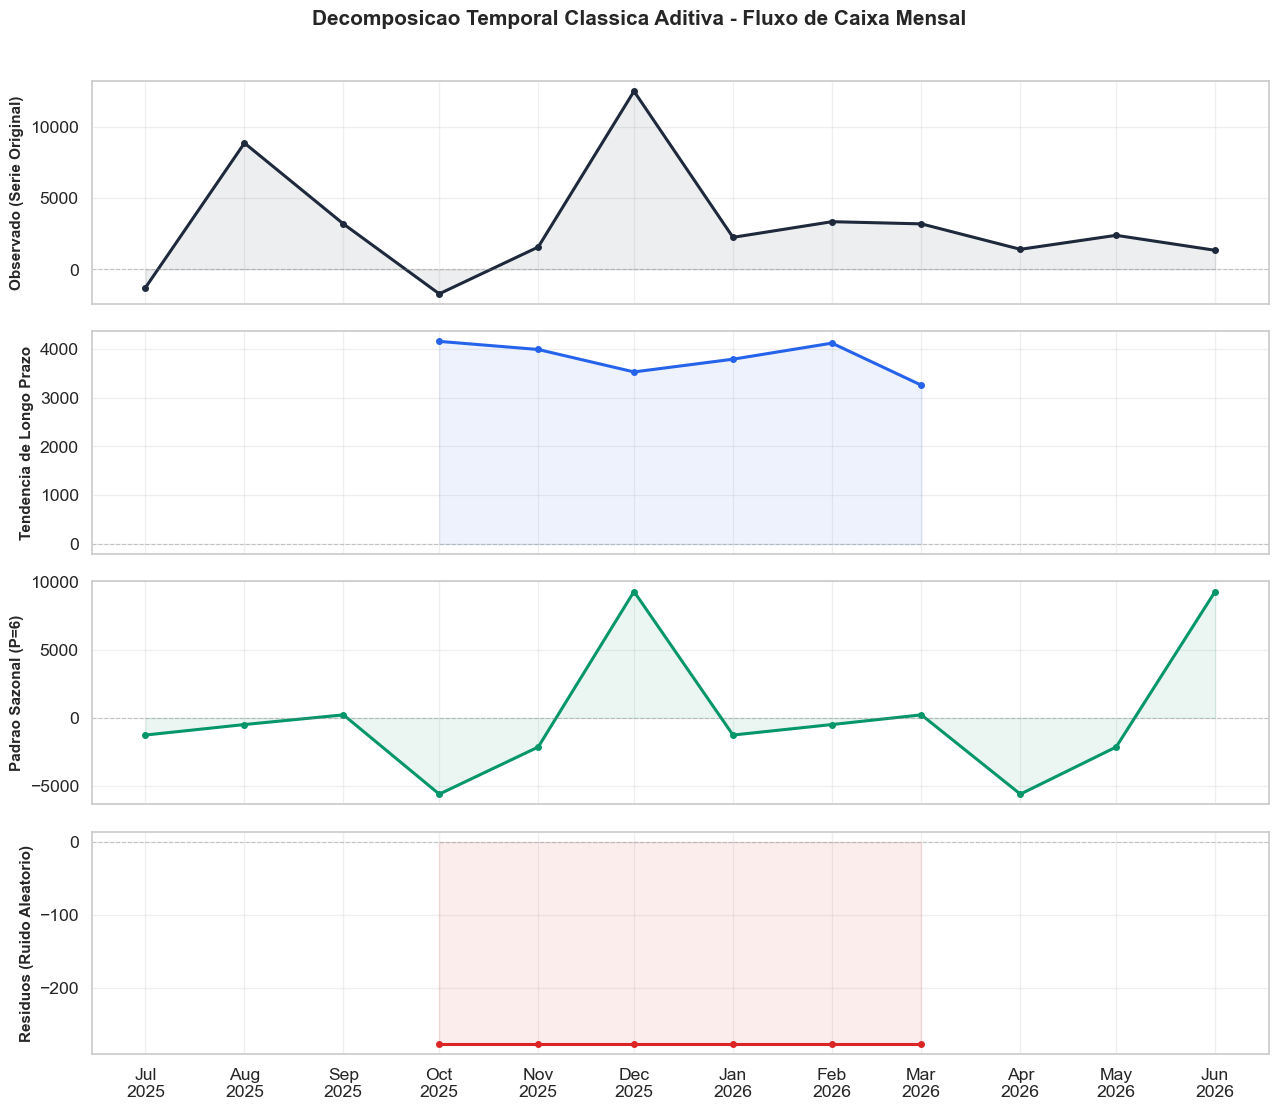

OK: Decomposicao temporal concluida.


In [3]:
# --- Decomposicao Temporal Classica Aditiva ---
# seasonal_decompose exige 2*period observacoes. Com 12 meses, usa periodo=6.

n_months = len(df)
decomp_period = n_months // 2  # maximo possivel: metade dos dados
decomp_period = max(2, decomp_period)  # minimo 2
decomp_title = f'Periodo = {decomp_period} meses'

print(f'Decomp: {decomp_title} (maximo para {n_months} observacoes)')

result = seasonal_decompose(df["balance"], model="additive", period=decomp_period)

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
components = [
    ("Observado (Serie Original)", result.observed, "#1e293b"),
    ("Tendencia de Longo Prazo", result.trend, "#2563eb"),
    (f"Padrao Sazonal (P={decomp_period})", result.seasonal, "#059669"),
    ("Residuos (Ruido Aleatorio)", result.resid, "#dc2626"),
]

for ax, (title, data, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=2.2, marker='o', markersize=4)
    ax.fill_between(data.index, data.values, alpha=0.08, color=color)
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.axhline(0, color="grey", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.suptitle("Decomposicao Temporal Classica Aditiva - Fluxo de Caixa Mensal",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("decomposicao_temporal.png", bbox_inches="tight")
plt.show()
print("OK: Decomposicao temporal concluida.")


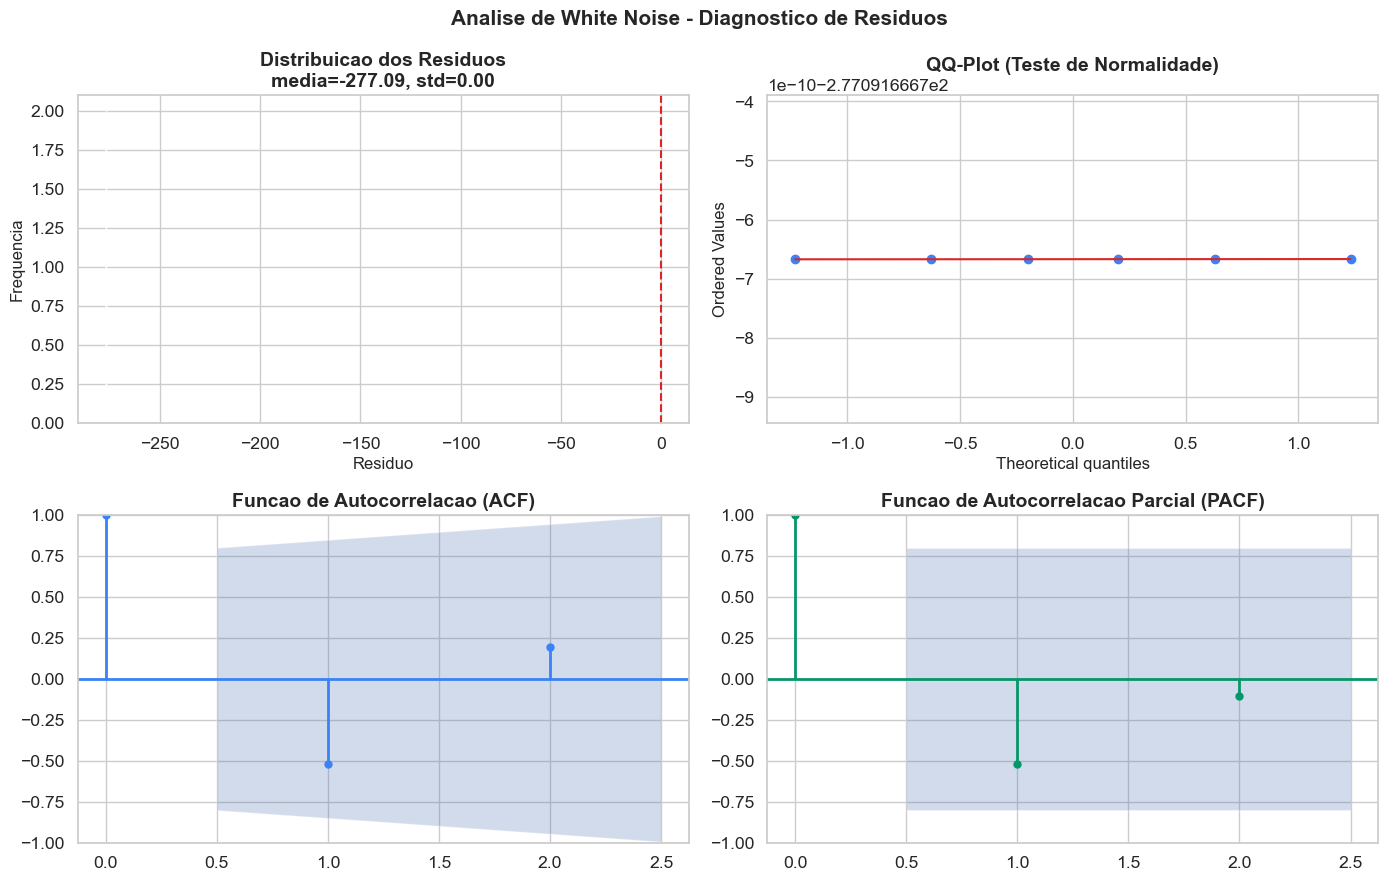

Teste de Ljung-Box (H0: residuos sao white noise):


,lb_stat,lb_pvalue
1,2.588166,0.107665
2,3.031953,0.219594


  Resultado: Nao rejeita H0 (p_min=0.1077 > 0.05) -> Residuos parecem ser white noise.


In [4]:
# --- Analise de White Noise (Ruido Branco) ---
# Verifica se os residuos da serie sao independentes e identicamente distribuidos.
# Teste de Ljung-Box: H0 = os dados sao white noise (p > 0.05 = NAO rejeita H0)

residuos = result.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Histograma dos residuos
ax = axes[0, 0]
ax.hist(residuos, bins=max(5, len(residuos)//3), color="#3b82f6", edgecolor="white", alpha=0.8)
ax.axvline(0, color="#dc2626", linestyle="--", linewidth=1.5)
mu, sigma = residuos.mean(), residuos.std()
ax.set_title(f"Distribuicao dos Residuos\nmedia={mu:.2f}, std={sigma:.2f}", fontweight="bold")
ax.set_xlabel("Residuo")
ax.set_ylabel("Frequencia")

# 2. QQ-Plot (normalidade)
ax = axes[0, 1]
stats.probplot(residuos, dist="norm", plot=ax)
ax.set_title("QQ-Plot (Teste de Normalidade)", fontweight="bold")
ax.get_lines()[0].set(marker='o', color='#3b82f6', markersize=6)
ax.get_lines()[1].set(color='#dc2626', linewidth=1.5)

# 3. ACF dos residuos
ax = axes[1, 0]
n_lags = min(10, len(residuos) // 2 - 1)
if n_lags > 0:
    plot_acf(residuos, lags=n_lags, ax=ax, color="#3b82f6", vlines_kwargs={"color": "#3b82f6"})
ax.set_title("Funcao de Autocorrelacao (ACF)", fontweight="bold")

# 4. PACF dos residuos
ax = axes[1, 1]
if n_lags > 0:
    plot_pacf(residuos, lags=n_lags, ax=ax, color="#059669", vlines_kwargs={"color": "#059669"})
ax.set_title("Funcao de Autocorrelacao Parcial (PACF)", fontweight="bold")

fig.suptitle("Analise de White Noise - Diagnostico de Residuos", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("white_noise_analysis.png", bbox_inches="tight")
plt.show()

# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
if len(residuos) > 5:
    lb_test = acorr_ljungbox(residuos, lags=min(5, len(residuos)//2 - 1), return_df=True)
    print('Teste de Ljung-Box (H0: residuos sao white noise):')
    display(lb_test)
    p_min = lb_test['lb_pvalue'].min()
    if p_min > 0.05:
        print(f'  Resultado: Nao rejeita H0 (p_min={p_min:.4f} > 0.05) -> Residuos parecem ser white noise.')
    else:
        print(f'  Resultado: Rejeita H0 (p_min={p_min:.4f} <= 0.05) -> Ha padroes nos residuos.')
else:
    print('Serie muito curta para teste de Ljung-Box (n < 6).')


In [5]:
# --- Classe HarmonicRegressionForecast ---
# OLS com Gauss-Jordan + pivoteamento parcial (Python puro)

Z95 = 1.96


class HarmonicRegressionForecast:
    """Regressao Harmonica Sazonal de segunda ordem (period=12)."""

    def __init__(self, period: int = 12):
        self.period = period
        self.beta: List[float] = []
        self._fitted = False

    @staticmethod
    def _design_matrix(n: int, period: int) -> List[List[float]]:
        A = []
        for i in range(n):
            t_i = float(i)
            A.append([1.0, t_i, math.sin(2*math.pi*t_i/period), math.cos(2*math.pi*t_i/period)])
        return A

    @staticmethod
    def _normal_equations(A, y):
        m, k = len(A), len(A[0])
        ATA = [[0.0]*k for _ in range(k)]
        ATy = [0.0]*k
        for i in range(m):
            for j in range(k):
                ATy[j] += A[i][j] * y[i]
                for jj in range(k):
                    ATA[j][jj] += A[i][j] * A[i][jj]
        return ATA, ATy

    @staticmethod
    def _gauss_jordan(A, b):
        n = len(A)
        aug = [row[:] + [b[i]] for i, row in enumerate(A)]
        for col in range(n):
            max_row = col
            max_val = abs(aug[col][col])
            for row in range(col+1, n):
                if abs(aug[row][col]) > max_val:
                    max_row, max_val = row, abs(aug[row][col])
            if max_val < 1e-12:
                raise ValueError("Matriz singular")
            if max_row != col:
                aug[col], aug[max_row] = aug[max_row], aug[col]
            pivot = aug[col][col]
            for j in range(col, n+1):
                aug[col][j] /= pivot
            for row in range(n):
                if row == col: continue
                factor = aug[row][col]
                for j in range(col, n+1):
                    aug[row][j] -= factor * aug[col][j]
        return [aug[i][n] for i in range(n)]

    def fit(self, y):
        n = len(y)
        A = self._design_matrix(n, self.period)
        ATA, ATy = self._normal_equations(A, y)
        self.beta = self._gauss_jordan(ATA, ATy)
        self._n_train, self._y, self._fitted = n, y, True
        return self

    def predict(self, steps):
        if not self._fitted:
            raise RuntimeError("Modelo nao ajustado.")
        n, y = self._n_train, self._y
        y_hat = [self._predict_single(float(i)) for i in range(n)]
        residuals = [yi - hi for yi, hi in zip(y, y_hat)]
        variance = sum(r*r for r in residuals) / max(n - len(self.beta), 1)
        std_err = math.sqrt(variance) if variance > 1e-10 else abs(y[-1]) * 0.05 or 1.0
        fc, lo, hi = [], [], []
        for step in range(1, steps+1):
            pred = self._predict_single(float(n - 1 + step))
            margin = Z95 * std_err * math.sqrt(step)
            fc.append(round(pred, 2))
            lo.append(round(pred - margin, 2))
            hi.append(round(pred + margin, 2))
        return {"forecast_values": fc, "lower_bound": lo, "upper_bound": hi,
                "method": "harmonic_seasonal", "std_err": round(std_err, 4),
                "beta": [round(b, 6) for b in self.beta]}

    def _predict_single(self, t):
        return (self.beta[0] + self.beta[1]*t
                + self.beta[2]*math.sin(2*math.pi*t/self.period)
                + self.beta[3]*math.cos(2*math.pi*t/self.period))

    def residuals(self):
        y_hat = [self._predict_single(float(i)) for i in range(self._n_train)]
        return [yi - hi for yi, hi in zip(self._y, y_hat)]


# --- Ajuste do modelo ---
y_train = df["balance"].tolist()

# Auto-select period based on data length
model_period = 12 if len(y_train) >= 12 else max(2, len(y_train) // 2)
model = HarmonicRegressionForecast(period=model_period).fit(y_train)
result_pred = model.predict(steps=6)

print(f"OK: Modelo ajustado (periodo={model_period})")
print(f"  Coeficientes: {result_pred['beta']}")
print(f"  Erro padrao:  {result_pred['std_err']}")
print()
print("Previsoes (6 meses):")
for i, (fc, lo, hi) in enumerate(
    zip(result_pred["forecast_values"], result_pred["lower_bound"], result_pred["upper_bound"]), 1):
    print(f"  Mes {i}: R$ {fc:>10,.2f}  [{lo:>10,.2f} -- {hi:>10,.2f}]")


OK: Modelo ajustado (periodo=12)
  Coeficientes: [3335.200618, -44.446779, 584.471108, -1379.362437]
  Erro padrao:  4467.502

Previsoes (6 meses):
  Mes 1: R$   1,422.48  [ -7,333.83 --  10,178.78]
  Mes 2: R$   1,855.07  [-10,528.22 --  14,238.35]
  Mes 3: R$   2,529.43  [-12,636.93 --  17,695.79]
  Mes 4: R$   3,252.97  [-14,259.64 --  20,765.58]
  Mes 5: R$   3,819.90  [-15,759.79 --  23,399.59]
  Mes 6: R$   4,066.40  [-17,382.07 --  25,514.88]


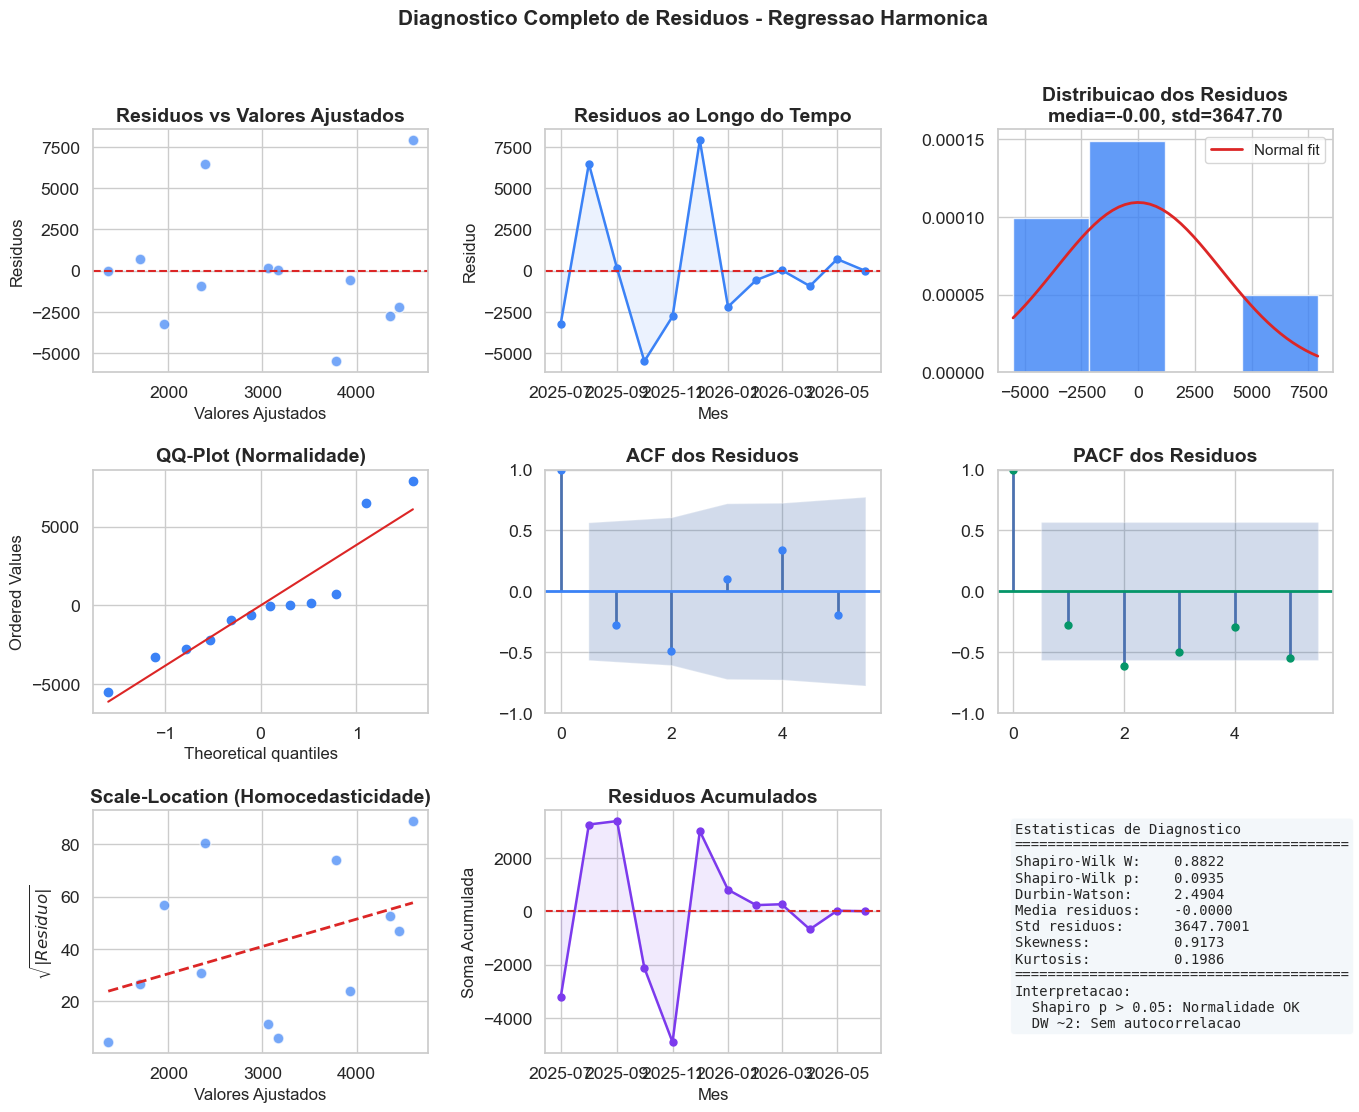

OK: Diagnostico de residuos concluido.


In [6]:
# --- Diagnostico de Residuos do Modelo ---
# Analise completa dos residuos da regressao harmonica.

resid_model = model.residuals()
resid_arr = np.array(resid_model)
y_hat_model = np.array([model._predict_single(float(i)) for i in range(len(y_train))])

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, hspace=0.4, wspace=0.35)

# 1. Residuos vs Ajustados
ax = fig.add_subplot(gs[0, 0])
ax.scatter(y_hat_model, resid_arr, color="#3b82f6", alpha=0.7, edgecolors="white", s=60)
ax.axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
ax.set_title("Residuos vs Valores Ajustados", fontweight="bold")
ax.set_xlabel("Valores Ajustados")
ax.set_ylabel("Residuos")

# 2. Residuos ao longo do tempo
ax = fig.add_subplot(gs[0, 1])
ax.plot(df.index, resid_arr, color="#3b82f6", marker="o", markersize=5, linewidth=1.8)
ax.axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
ax.fill_between(df.index, resid_arr, alpha=0.1, color="#3b82f6")
ax.set_title("Residuos ao Longo do Tempo", fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Residuo")

# 3. Histograma dos residuos
ax = fig.add_subplot(gs[0, 2])
ax.hist(resid_arr, bins=max(3, len(resid_arr)//3), color="#3b82f6", edgecolor="white", alpha=0.8, density=True)
x_range = np.linspace(resid_arr.min(), resid_arr.max(), 50)
ax.plot(x_range, stats.norm.pdf(x_range, resid_arr.mean(), resid_arr.std()),
        color="#dc2626", linewidth=2, label="Normal fit")
ax.set_title(f"Distribuicao dos Residuos\nmedia={resid_arr.mean():.2f}, std={resid_arr.std():.2f}", fontweight="bold")
ax.legend()

# 4. QQ-Plot
ax = fig.add_subplot(gs[1, 0])
stats.probplot(resid_arr, dist="norm", plot=ax)
ax.set_title("QQ-Plot (Normalidade)", fontweight="bold")
ax.get_lines()[0].set(marker='o', color='#3b82f6', markersize=6)
ax.get_lines()[1].set(color='#dc2626', linewidth=1.5)

# 5. ACF
ax = fig.add_subplot(gs[1, 1])
n_lags = min(8, len(resid_arr) // 2 - 1)
if n_lags > 0:
    plot_acf(resid_arr, lags=n_lags, ax=ax, color="#3b82f6")
ax.set_title("ACF dos Residuos", fontweight="bold")

# 6. PACF
ax = fig.add_subplot(gs[1, 2])
if n_lags > 0:
    plot_pacf(resid_arr, lags=n_lags, ax=ax, color="#059669")
ax.set_title("PACF dos Residuos", fontweight="bold")

# 7. Scale-Location (sqrt |residuos| vs ajustados)
ax = fig.add_subplot(gs[2, 0])
sqrt_abs_resid = np.sqrt(np.abs(resid_arr))
ax.scatter(y_hat_model, sqrt_abs_resid, color="#3b82f6", alpha=0.7, edgecolors="white", s=60)
z = np.polyfit(y_hat_model, sqrt_abs_resid, 1)
ax.plot(sorted(y_hat_model), np.polyval(z, sorted(y_hat_model)), color="#dc2626", linestyle="--")
ax.set_title("Scale-Location (Homocedasticidade)", fontweight="bold")
ax.set_xlabel("Valores Ajustados")
ax.set_ylabel(r"$\sqrt{|Residuo|}$")

# 8. Residuos acumulados
ax = fig.add_subplot(gs[2, 1])
cum_resid = np.cumsum(resid_arr)
ax.plot(df.index, cum_resid, color="#7c3aed", marker="o", markersize=5, linewidth=1.8)
ax.axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
ax.fill_between(df.index, cum_resid, alpha=0.1, color="#7c3aed")
ax.set_title("Residuos Acumulados", fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Soma Acumulada")

# 9. Estatisticas de diagnostico
ax = fig.add_subplot(gs[2, 2])
ax.axis("off")
sw_stat, sw_pval = stats.shapiro(resid_arr) if len(resid_arr) >= 3 else (0, 1)
dw_stat = np.sum(np.diff(resid_arr)**2) / np.sum(resid_arr**2) if len(resid_arr) > 1 else 0
stats_text = (
    f"Estatisticas de Diagnostico\n"
    f"{'='*40}\n"
    f"Shapiro-Wilk W:    {sw_stat:.4f}\n"
    f"Shapiro-Wilk p:    {sw_pval:.4f}\n"
    f"Durbin-Watson:     {dw_stat:.4f}\n"
    f"Media residuos:    {resid_arr.mean():.4f}\n"
    f"Std residuos:      {resid_arr.std():.4f}\n"
    f"Skewness:          {stats.skew(resid_arr):.4f}\n"
    f"Kurtosis:          {stats.kurtosis(resid_arr):.4f}\n"
    f"{'='*40}\n"
    f"Interpretacao:\n"
    f"  Shapiro p {">" if sw_pval > 0.05 else "<="} 0.05: Normalidade {"OK" if sw_pval > 0.05 else "Rejeitada"}\n"
    f"  DW ~2: {'Sem autocorrelacao' if 1.5 < dw_stat < 2.5 else 'Possivel autocorrelacao'}"
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f1f5f9', alpha=0.8))

fig.suptitle("Diagnostico Completo de Residuos - Regressao Harmonica", fontsize=15, fontweight="bold")
plt.savefig("residual_diagnostics.png", bbox_inches="tight")
plt.show()
print("OK: Diagnostico de residuos concluido.")


In [7]:
# --- Validacao Cruzada: Walk-Forward ---
# Periodo dinamico: min(12, n_treino // 2) para evitar instabilidade com poucos dados.

HORIZON = min(3, len(y_train) // 3)
y_full = df["balance"].values
n = len(y_full)

harmonic_errors: List[Dict] = []

print(f"Walk-Forward Validation (horizonte={HORIZON})")
print("=" * 80)
print(f"{'Janela':<12} {'Treino':<8} {'Teste':<8} {'MAE':>12} {'RMSE':>12} {'MAPE':>10}")
print("-" * 80)

for start in range(n - HORIZON):
    train = y_full[:start + 1].tolist()
    test  = y_full[start + 1 : start + 1 + HORIZON].tolist()
    if len(test) < HORIZON or len(train) < 4:
        continue
    try:
        # Periodo dinamico: metade do treino, no maximo 12
        dynamic_period = min(12, max(2, len(train) // 2))
        m = HarmonicRegressionForecast(period=dynamic_period).fit(train)
        pred = m.predict(steps=HORIZON)["forecast_values"]
        mae  = mean_absolute_error(test, pred)
        rmse = math.sqrt(mean_squared_error(test, pred))
        # MAPE: evitar divisao por zero
        test_arr = np.array(test)
        pred_arr = np.array(pred)
        mask = np.abs(test_arr) > 1e-6  # excluir valores proximos de zero
        if mask.sum() > 0:
            mape = np.mean(np.abs((test_arr[mask] - pred_arr[mask]) / test_arr[mask])) * 100
        else:
            mape = float("nan")
    except Exception:
        mae, rmse, mape = float("nan"), float("nan"), float("nan")
    window_label = f"{start+1}-->{start+HORIZON+1}"
    print(f"{window_label:<12} {len(train):<8} {HORIZON:<8} {mae:>12.2f} {rmse:>12.2f} {mape:>9.2f}%")
    harmonic_errors.append({"mae": mae, "rmse": rmse, "mape": mape})

print("-" * 80)

maes = [e['mae'] for e in harmonic_errors if not math.isnan(e['mae'])]
rmses = [e['rmse'] for e in harmonic_errors if not math.isnan(e['rmse'])]
mapes = [e['mape'] for e in harmonic_errors if not math.isnan(e['mape'])]
if maes:
    print(f"MAE medio:  R$ {np.mean(maes):,.2f}")
    if rmses:
        print(f"RMSE medio: R$ {np.mean(rmses):,.2f}")
    if mapes:
        print(f"MAPE medio: {np.mean(mapes):.2f}%")
else:
    print("Dados insuficientes para validacao walk-forward.")
print("OK: Walk-Forward concluido.")


Walk-Forward Validation (horizonte=3)
Janela       Treino   Teste             MAE         RMSE       MAPE
--------------------------------------------------------------------------------
4-->7        4        3                 nan          nan       nan%
5-->8        5        3                 nan          nan       nan%
6-->9        6        3             3687.58      3892.79    127.07%
7-->10       7        3             4142.86      4723.28    145.67%
8-->11       8        3             8029.87      8826.33    446.35%
9-->12       9        3             5916.51      7143.91    362.64%
--------------------------------------------------------------------------------
MAE medio:  R$ 5,444.20
RMSE medio: R$ 6,146.58
MAPE medio: 270.43%
OK: Walk-Forward concluido.


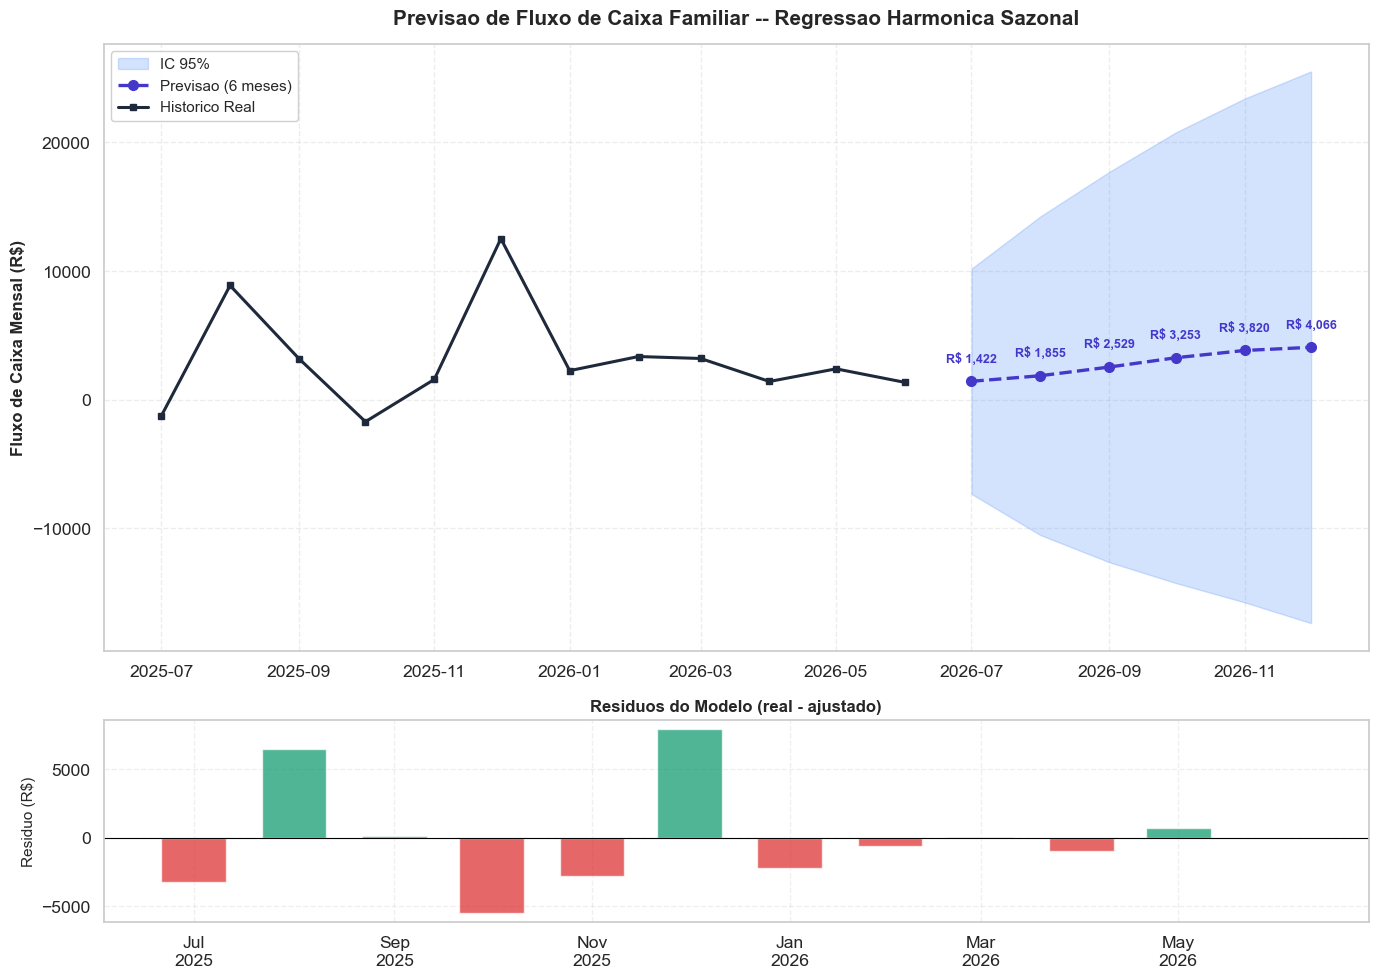

RESUMO DO MODELO PREDITIVO
  Metodo:            harmonic_seasonal
  Periodo sazonal:   12 meses
  Parametros (beta): [3335.200618, -44.446779, 584.471108, -1379.362437]
  Erro padrao (SE):  4467.502
  Historico:         12 meses
  Horizonte:         6 meses

  Previsoes com IC 95%:
    Jul/2026:  R$   1,422.48  [ -7,333.83 --  10,178.78]
    Aug/2026:  R$   1,855.07  [-10,528.22 --  14,238.35]
    Sep/2026:  R$   2,529.43  [-12,636.93 --  17,695.79]
    Oct/2026:  R$   3,252.97  [-14,259.64 --  20,765.58]
    Nov/2026:  R$   3,819.90  [-15,759.79 --  23,399.59]
    Dec/2026:  R$   4,066.40  [-17,382.07 --  25,514.88]


In [8]:
# --- Grafico definitivo de entrega ---

FORECAST_MONTHS = 6
hist_dates = df.index
hist_vals  = df["balance"].values

pred = model.predict(steps=FORECAST_MONTHS)
fc_dates = pd.date_range(start=hist_dates[-1] + pd.offsets.MonthBegin(1),
                         periods=FORECAST_MONTHS, freq="MS")
fc_vals  = np.array(pred["forecast_values"])
fc_lower = np.array(pred["lower_bound"])
fc_upper = np.array(pred["upper_bound"])

fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

# --- Plot principal ---
ax = axes[0]
ax.fill_between(fc_dates, fc_lower, fc_upper, alpha=0.22, color="#3b82f6", label="IC 95%")
ax.plot(fc_dates, fc_vals, color="#4338ca", linestyle="--", marker="o", markersize=7,
        linewidth=2.4, label=f"Previsao ({FORECAST_MONTHS} meses)")
ax.plot(hist_dates, hist_vals, color="#1e293b", linestyle="-", marker="s", markersize=5,
        linewidth=2.2, label="Historico Real")

for d, v in zip(fc_dates, fc_vals):
    ax.annotate(f"R$ {v:,.0f}", (d, v), textcoords="offset points", xytext=(0, 14),
                ha="center", fontsize=9, fontweight="bold", color="#4338ca")

ax.set_title("Previsao de Fluxo de Caixa Familiar -- Regressao Harmonica Sazonal",
             fontsize=15, fontweight="bold", pad=14)
ax.set_ylabel("Fluxo de Caixa Mensal (R$)", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.92, fontsize=11)
ax.grid(True, alpha=0.35, linestyle="--")

# --- Plot de residuos ---
ax = axes[1]
resid_plot = model.residuals()
ax.bar(hist_dates, resid_plot, color=["#059669" if r >= 0 else "#dc2626" for r in resid_plot],
       alpha=0.7, width=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residuos do Modelo (real - ajustado)", fontsize=12, fontweight="bold")
ax.set_ylabel("Residuo (R$)", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("previsao_final.png", bbox_inches="tight", facecolor="white")
plt.show()

print("=" * 70)
print("RESUMO DO MODELO PREDITIVO")
print("=" * 70)
print(f"  Metodo:            {pred['method']}")
print(f"  Periodo sazonal:   {model_period} meses")
print(f"  Parametros (beta): {pred['beta']}")
print(f"  Erro padrao (SE):  {pred['std_err']}")
print(f"  Historico:         {len(hist_vals)} meses")
print(f"  Horizonte:         {FORECAST_MONTHS} meses")
print()
print("  Previsoes com IC 95%:")
for i, (d, fc, lo, hi) in enumerate(zip(fc_dates, fc_vals, fc_lower, fc_upper), 1):
    print(f"    {d:%b/%Y}:  R$ {fc:>10,.2f}  [{lo:>10,.2f} -- {hi:>10,.2f}]")
print("=" * 70)
